In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from dataclasses import dataclass
import scipy.sparse.linalg as lng
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import curve_fit
import time
from scipy.interpolate import RegularGridInterpolator

@dataclass(frozen = True)
class Params: 
    r : float
    R : float
    kappa : float
    vs : float
    a : float
    sig_x : float
    sig_y : float
    X_min : float
    X_max : float
    Y_min : float
    Y_max : float

params = Params(
    r = .5,
    R = np.sqrt(2),
    kappa = .1,
    vs = .5,
    a = .2,
    sig_x = .5,
    sig_y = .2,
    X_min = -2.0,
    X_max = 2.0,
    Y_min = -2.0,
    Y_max = 2.0
)

## Etape 0 : définir la grille
Dans la suite, on considère que l'on travaille sur un carré, et que notre discrétisation en x et y sera toujours homogène. mon idée ici est alors de créer une fonction qui fonctionnera comme un masque, c'est a dire une fonction qui a N renvoie une matrice qui contient des 1 (la ou on peut naviguer) et des zéros (là ou on ne peut pas). Cela permettra de faciliter la définition de la matrice des différencre finies.  

Pour définir les cercles concentriques, on va considérer que le carré sur lequel on se trouve a pour dimension N*N, et on adaptera dans les codes suivants. 

In [3]:


def grid_radius(x,y): 
    X,Y = np.meshgrid(x,y)
    return np.sqrt(X**2 + Y**2)

def make_masks(x,y, params):
    rad = grid_radius(x,y) 
    mask_0 = (rad <= params.r)
    mask_1 = (rad >= params.R)
    mask_PDE = (~mask_0) & (~mask_1)
    return mask_0, mask_PDE, mask_1


## Définition des différences finies
Nous allons d'abord définir une matrice de différences finies, puis adapter sur l'espace que l'on considère. 


On définit encore des fonctions Alpha et Beta telles que données dans le sujet. Pour lorsque les gradients sont nuls (cas de manque de définition des fonctions), nous choisissons d'introduire un "0 machine" pour conserver le cractère bien défini de nos fonctions

In [4]:
## Différences finies: 
def D_1_X_sparse(Nx,Ny, params): 
    h = (params.X_max - params.X_min)/Nx
    N = (Nx+1)*(Ny+1)
    diag_p = np.ones(N - 1)
    diag_m = np.ones(N - 1)
    for j in range(Ny + 1):
        idx = j * (Nx + 1) + Nx   
        if idx < N - 1:
            diag_p[idx] = 0       
    for j in range(Ny + 1):
        idx = j * (Nx + 1)        
        if idx > 0:
            diag_m[idx - 1] = 0 
    D = sparse.diags(diagonals = [-diag_m, diag_p], offsets = [-1,1])/(2*h)
    return D

def D_1_Y_sparse(Nx, Ny, params): 
    k = (params.Y_max - params.Y_min)/Ny
    vect_0 = np.ones((Nx + 1) * (Ny + 1))
    D = sparse.diags(diagonals = [-vect_0[Nx+1:], vect_0[:-Nx-1]], offsets = [-Nx-1, Nx+1]) / (2*k)
    return D    

def Grad_sparse(Nx, Ny, params): 
    Dx = D_1_X_sparse(Nx, Ny, params)
    Dy = D_1_Y_sparse(Nx, Ny, params)
    return Dx, Dy

def D_2_X_sparse(Nx, Ny, params): 
    h = (params.X_max - params.X_min)/Nx
    N = (Nx + 1) * (Ny + 1)
    
    diag_0  = -2 * np.ones(N)
    diag_p =       np.ones(N - 1)
    diag_m =       np.ones(N - 1)
    for j in range(Ny + 1):
        idx = j * (Nx + 1) + Nx   
        if idx < N - 1:
            diag_p[idx] = 0       
    for j in range(Ny + 1):
        idx = j * (Nx + 1)        
        if idx > 0:
            diag_m[idx - 1] = 0 
    D = sparse.diags(diagonals = [diag_m, diag_0, diag_p], offsets = [-1, 0, 1]) / h**2
    return D

def D_2_Y_sparse(Nx, Ny, params):
    k = (params.Y_max - params.Y_min)/Ny
    N = (Nx + 1) * (Ny + 1)
    
    diag_0  = -2 * np.ones(N)
    diag_p =      np.ones(N - (Nx + 1))
    diag_m =      np.ones(N - (Nx + 1))

    D = sparse.diags(diagonals = [diag_p, diag_0, diag_m], offsets = [-Nx-1, 0, Nx+1]) / k**2
    return D

def alpha(U, Nx, Ny, params): 
    N = (Nx+1)*(Ny+1)
    D_x, D_y = Grad_sparse(Nx, Ny, params)
    norm = np.sqrt((D_x @U)**2 + (D_y @ U)**2)
    norm = np.where(norm == 0, 1, norm)
    return D_x@U/norm, D_y@U/norm

def beta(U, Nx, Ny, params): 
    D_x, D_y= Grad_sparse(Nx, Ny, params)
    return np.sign(D_x@U), np.sign(D_y@U)

def vc_field(X, Y, params):
    XX,YY = np.meshgrid(X,Y)
    s = ((XX**2+YY**2) - params.r**2) / (params.R**2 - params.r**2)
    #print (s.shape)
    return 1.0 - params.a * np.sin(np.pi * s)

In [5]:
def build_system(U, x, y, N, f, params) :
    ## pour etre sur de traiter avec la forme dont on a besoin
    U.flatten()
    
    ##matrices de différences finies
    Dx = D_1_X_sparse(N,N, params)
    Dy = D_1_Y_sparse(N,N, params)
    Dxx = D_2_X_sparse(N,N, params)
    Dyy = D_2_Y_sparse(N,N, params)
    ## matrice et coefficients a partir du U
    ax, ay = alpha(U, N, N, params)
    bx, by = beta(U,N,N, params)
    #print (x.shape, y.shape)
    VC = vc_field(x, y, params)
    #print (VC.shape)
    VC = VC.flatten()
    #print(VC.shape)
    ## ordre 2
    A = (-.5*params.sig_x**2 * Dxx -.5*params.sig_y**2 * Dyy) 
    ## vents : 
    A = A - sparse.diags(VC) @ Dx
    ## termes en alpha
    A = A + params.vs * (sparse.diags(ax)@Dx + sparse.diags(ay)@Dy)
    ## termes en beta
    A = A - params.kappa * (sparse.diags(bx) @ Dx + sparse.diags(by)@Dy)

    ## second membre 
    XX,YY = np.meshgrid(x,y)
    B = f(XX,YY).flatten()
    m1, m2, m3 = make_masks(x, y, params)
    m1 = m1.flatten()
    m2 = m2.flatten()
    m3 = m3.flatten()
    A = A.tolil()
    #print(m1.shape)
    bd_idx = np.where(~m2)[0]
    for i in bd_idx: 
        A[i,:] = 0
        A[i,i] = 1.0
        if m1[i]:
            B[i] = .0
        else : 
            B[i] = 1.0
    A = A.tocsr()
    return A, B
    

In [15]:
x, y, = np.linspace(params.X_min, params.X_max, 21), np.linspace(params.Y_min, params.Y_max, 21)
U = np.zeros(400)
A,B = build_system(U, x, y, 20, f_1, params)
print(B)

ValueError: dimension mismatch

In [9]:
def Solveur_Zermelo (N, f,params, tol = 1e-6, max_iter = 200):
    x, y = np.linspace(params.X_min, params.X_max, N+1), np.linspace(params.Y_min, params.Y_max, N+1)
    XX, YY = np.meshgrid(x, y)

    mask_in, mask_pde, mask_out = make_masks(x, y, params)
    f_vec = f(XX,YY).flatten()

    U_vec = np.zeros((N+1)*(N+1))
    ##initialiser les bords : 
    mask_out = mask_out.flatten()
    U_vec[mask_out] = 1.0

    for n in range(max_iter):
        A,B = build_system(U_vec, x, y, N,f, params)
        U_next = lng.spsolve(A,B)

        err = np.max(np.abs(U_next - U_vec))
        U_vec = U_next
        if err < tol: 
            break
    U = U_vec.reshape(N+1, N+1)
    U[~mask_pde] = np.nan
    return U , x, y



In [10]:
def u_exact(XX, YY):
    return np.sin(0.5 * np.pi * (XX**2 + YY**2 - r**2) / (R**2 - r**2))

def compute_f_exact(XX, YY, hx=1e-5, hy=1e-5):
    """
    Calcul numérique du second membre f tel que u_exact soit solution de l'EDP.
    On évalue F(x, u, ∇u, D²u) avec les dérivées analytiques de u_exact.
   """
    phi = (XX**2 + YY**2 - params.r**2) / (params.R**2 - params.r**2)
    c   = 0.5 * np.pi / (params.R**2 - params.r**2)
    # Dérivées de uex = sin(pi/2 * phi)
    ux  =  c * np.cos(0.5*np.pi*phi) * 2*XX
    uy  =  c * np.cos(0.5*np.pi*phi) * 2*YY
    uxx = -c**2 * np.sin(0.5*np.pi*phi) * (2*XX)**2 + c * np.cos(0.5*np.pi*phi) * 2
    uyy = -c**2 * np.sin(0.5*np.pi*phi) * (2*YY)**2 + c * np.cos(0.5*np.pi*phi) * 2

    norm2 = np.sqrt(ux**2 + uy**2)
    norm1 = np.abs(ux) + np.abs(uy)

    VC = 1 - params.a * np.sin(np.pi * phi)

    # f = -1/2 σx² uxx - 1/2 σy² uyy - vc*ux + vs*||∇u||_2 - κ*||∇u||_1
    f = (- 0.5*params.sig_x**2 * uxx
         - 0.5*params.sig_y**2 * uyy
         - VC * ux
         + params.vs * norm2
         - params.kappa * norm1)
    return f

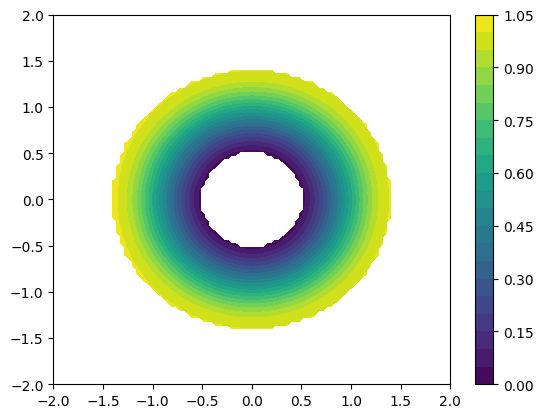

In [11]:
U, x, y = Solveur_Zermelo(100, compute_f_exact, params)


m,n,p = make_masks(x,y,params)


plt.figure()
U[~n] = np.nan
X,Y = np.meshgrid(x,y)
plt.contourf(X,Y,U, 20)
plt.colorbar()
plt.show()

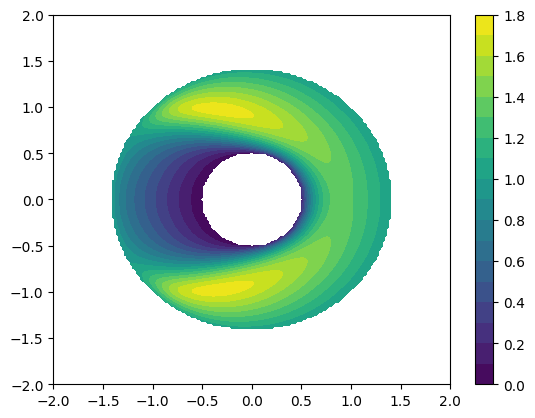

In [12]:
def f_1(x,y): 
    N = len(x)
    return np.ones(N*N)
U, x, y = Solveur_Zermelo(200, f_1, params)


m,n,p = make_masks(x,y,params)


plt.figure()
U[~n] = np.nan
X,Y = np.meshgrid(x,y)
plt.contourf(X,Y,U, 20)
plt.colorbar()
plt.show()

## Etudes des convergences
### 1. Cas où la solution exacte est connue :
Dans le 1er cas, on va pouvoir comparer avec la solution exacte pour extraire les ordres de convergence de notre méthode : 


In [13]:
    
def graphs_convergence(N_list, func, params):
    errors = []
    H = []
    Time = []
    U_prev, x_prev, y_prev = None, None, None
    for N in N_list: 
        
        H.append((params.X_max - params.X_min) / N)

        t0 = time.time()
        U_next, x_next, y_next = Solveur_Zermelo(N, func, params)
        t1 = time.time()
        Time.append((t1 - t0))
        
        if U_prev is not None: 
            interp = RegularGridInterpolator(
                (y_prev, x_prev), U_prev,   # grille précédente (grossière)
                method='linear',
                bounds_error=False,
                fill_value= np.nan
                )
            YY, XX = np.meshgrid(y_next, x_next, indexing='ij')
            pts = np.stack([YY.ravel(), XX.ravel()], axis=-1)
            U_prev_on_fine = interp(pts).reshape(len(y_next), len(x_next))
            diff = np.abs(U_next - U_prev_on_fine)

            m,n,p = make_masks(x_next, y_next, params)
            diff = diff[n]
            
            err = np.nanmax(diff)
            errors.append(err)
        U_prev, x_prev, y_prev = U_next, x_next, y_next
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.loglog(N_list[1:], errors, 'o-', label='erreur (grilles successives)')
    ax.loglog(N_list[1:], [errors[1] * (N_list[1]/N_list[i+1])**1 for i in range(len(errors))],
              'k--', label='O(h¹)')
    ax.loglog(N_list[1:], [errors[1] * (N_list[1]/N_list[i+1])**2 for i in range(len(errors))],
              'r--', label='O(h²)')
    ax.set_xlabel('N'); ax.set_ylabel('Erreur L∞')
    ax.set_title('Convergence en h')
    ax.legend(); ax.grid(True, which='both')
    
    ax2 = axes[1]
    ax2.loglog(N_list, Time, 's')
    ax2.set_xlabel('N(taille grille)')
    ax2.set_ylabel('Temps(s)')
    ax2.set_title('temps de calcul')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    return errors, H, Time
    
        
        

/var/folders/cv/xff8sw1n499f6g5nfkpzy48w0000gn/T/ipykernel_7970/194443344.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


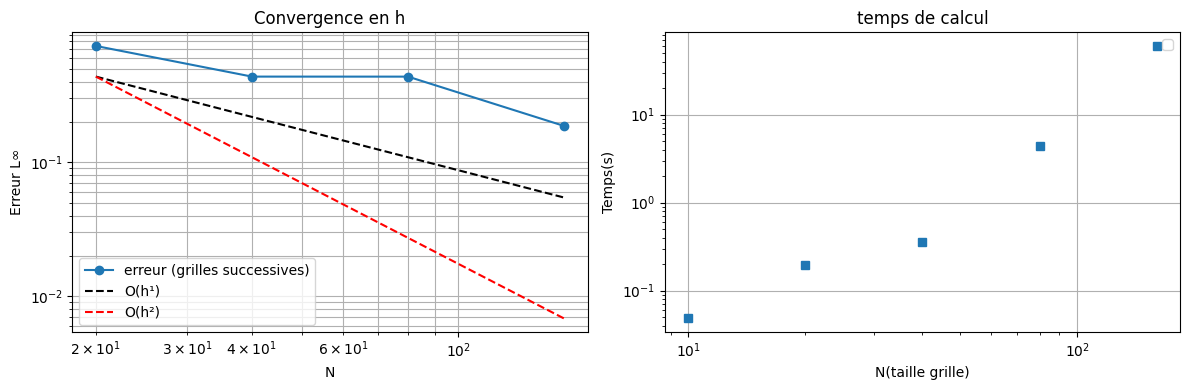

([np.float64(0.7397575024671195),
  np.float64(0.43680176017825245),
  np.float64(0.43655974119966434),
  np.float64(0.18699235026298366)],
 [0.4, 0.2, 0.1, 0.05, 0.025],
 [0.04827284812927246,
  0.1948380470275879,
  0.35505008697509766,
  4.462033033370972,
  60.369168758392334])

In [225]:
N_list = [10*2**k for k in range(5)]
graphs_convergence(N_list, f_1, params)

/var/folders/cv/xff8sw1n499f6g5nfkpzy48w0000gn/T/ipykernel_7970/194443344.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


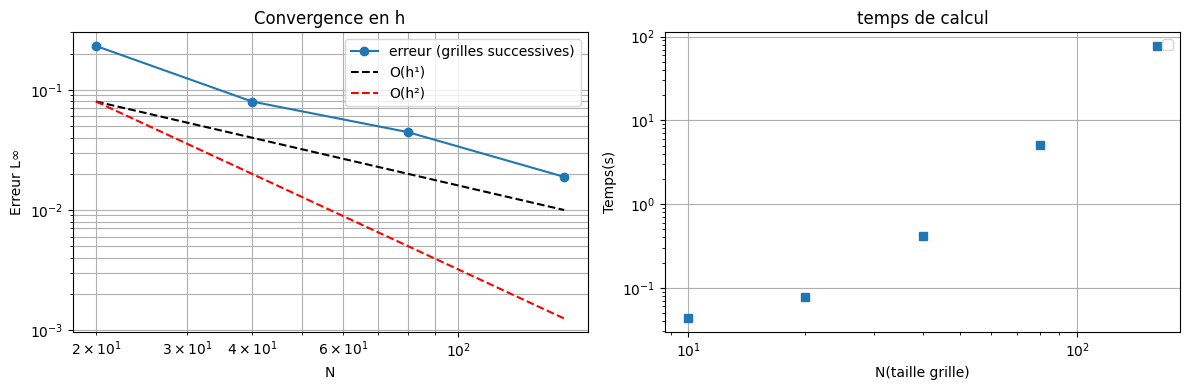

([np.float64(0.23153232661376544),
  np.float64(0.07980507481782873),
  np.float64(0.04435616441433421),
  np.float64(0.018834617735863667)],
 [0.4, 0.2, 0.1, 0.05, 0.025],
 [0.04288816452026367,
  0.07752013206481934,
  0.41511988639831543,
  5.064838171005249,
  77.43433499336243])

In [226]:
N_list = [10*2**k for k in range(5)]
graphs_convergence(N_list, compute_f_exact, params)